In [23]:
# Crear una lista con los nombres de los paquetes necesarios para el proyecto
paquetes <- c(
  "readxl",    # Permite leer archivos Excel (.xls y .xlsx)
  "readr",     # Facilita la lectura y escritura de archivos de texto y CSV
  "writexl",   # Permite exportar datos a archivos Excel (.xlsx)
  "forecast",  # Proporciona herramientas para modelado y pronóstico (ARIMA, ETS, etc.)
  "tseries",   # Incluye funciones para analisis de series temporales
  "astsa",     # Contiene funciones adicionales para analisis de series temporales (ej. sarima.for)
  "reticulate",# Permite integrar y ejecutar código Python desde R (opcional)
  "here"       # Facilita el manejo de rutas relativas dentro del proyecto
)

# Verifica que paquetes de la lista no estan instalados actualmente en el sistema
faltan <- setdiff(paquetes, rownames(installed.packages()))

# Si hay paquetes faltantes, los instala junto con sus dependencias
if (length(faltan)) install.packages(faltan, dependencies = TRUE)

In [24]:
# Carga las librerias necesarias para el proyecto en la sesion actual de R

library(readxl)     # Para leer archivos Excel
library(readr)      # Para leer y escribir datos en formato texto/CSV
library(writexl)    # Para exportar datos a archivos Excel
library(forecast)   # Para modelar y pronosticar series temporales
library(tseries)    # Para analisis de series temporales
library(astsa)      # Para funciones adicionales de analisis de series temporales
library(here)       # Para manejar rutas relativas de forma segura

In [25]:
# Elimina la carpeta local del proyecto si ya existe, para evitar conflictos con versiones anteriores
system("rm -rf portafolio-analisis-de-datos")

# Clona desde GitHub la ultima version del repositorio indicado
system("git clone https://github.com/vzoccola/portafolio-analisis-de-datos.git")

# Cambia el directorio de trabajo actual a la carpeta del proyecto recien clonada
setwd("portafolio-analisis-de-datos")

# Verifica la ubicación actual del directorio de trabajo
# Deberia mostrar: /content/portafolio-analisis-de-datos
getwd()

[1] "/content/portafolio-analisis-de-datos/portafolio-analisis-de-datos"

In [26]:
# Define la ruta al archivo Excel, uniendo las carpetas y el nombre del archivo
# Tasas de mortalidad para hombres y mujeres de Chile, desde año 1992 a 2019
ruta_excel <- file.path("projects", "deuda-publica-pensiones-chile", "data", "Deaths Rates.xlsx")

# Lee tasas de mortalidad desde la hoja "CL_H" (hombres) del archivo Excel
hm.cl <- read_excel(ruta_excel, sheet = "CL_H")

# Lee tasas de mortalidad desde la hoja "CL_M" (mujeres) del archivo Excel
ml.cl <- read_excel(ruta_excel, sheet = "CL_M")

# Muestra las primeras filas del conjunto de datos de hombres
head(hm.cl)

# Muestra las primeras filas del conjunto de datos de mujeres
head(ml.cl)

1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,⋯,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.016239,0.015060,0.013642,0.012603,0.012914,0.011381,0.012043,0.011627,0.010245,0.009845,⋯,0.007803,0.007847,0.007856,0.007587,0.007472,0.007501,0.007266,0.006952,0.006116,0.281570
0.001563,0.001372,0.001191,0.001284,0.001123,0.000528,0.000681,0.000429,0.000464,0.001034,⋯,0.000572,0.000537,0.000428,0.000488,0.000347,0.000391,0.000491,0.000540,0.000407,0.020911
0.000927,0.000599,0.000683,0.000650,0.000516,0.000707,0.000909,0.000625,0.000781,0.000531,⋯,0.000213,0.000255,0.000306,0.000223,0.000263,0.000252,0.000357,0.000375,0.000297,0.013356
0.000738,0.000469,0.000505,0.000500,0.000436,0.000502,0.000516,0.000419,0.000384,0.000447,⋯,0.000304,0.000206,0.000271,0.000161,0.000232,0.000181,0.000252,0.000212,0.000188,0.009866
0.000313,0.000379,0.000385,0.000448,0.000317,0.000293,0.000408,0.000340,0.000474,0.000310,⋯,0.000205,0.000240,0.000285,0.000168,0.000170,0.000166,0.000198,0.000187,0.000213,0.007724
0.000259,0.000282,0.000407,0.000336,0.000314,0.000478,0.000329,0.000299,0.000230,0.000261,⋯,0.000177,0.000139,0.000177,0.000175,0.000192,0.000097,0.000124,0.000148,0.000106,0.006766


1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,⋯,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.013842,0.012412,0.011797,0.010515,0.010705,0.009528,0.009868,0.009522,0.009084,0.008401,⋯,0.007321,0.006933,0.006222,0.007095,0.006029,0.006481,0.006607,0.006187,0.005643,0.004764
0.001104,0.001029,0.000902,0.001294,0.000849,0.000456,0.000444,0.000439,0.000391,0.000731,⋯,0.000393,0.000522,0.000476,0.000341,0.000482,0.000504,0.000432,0.000463,0.000374,0.000320
0.000672,0.000714,0.000367,0.000574,0.000326,0.000674,0.000853,0.000749,0.000558,0.000474,⋯,0.000274,0.000230,0.000257,0.000251,0.000223,0.000205,0.000152,0.000211,0.000241,0.000159
0.000361,0.000367,0.000425,0.000316,0.000343,0.000493,0.000384,0.000349,0.000240,0.000348,⋯,0.000204,0.000183,0.000140,0.000233,0.000235,0.000198,0.000154,0.000186,0.000203,0.000204
0.000300,0.000208,0.000258,0.000453,0.000264,0.000313,0.000296,0.000238,0.000215,0.000217,⋯,0.000210,0.000171,0.000209,0.000206,0.000133,0.000160,0.000164,0.000086,0.000152,0.000150
0.000219,0.000322,0.000299,0.000200,0.000240,0.000308,0.000246,0.000259,0.000223,0.000207,⋯,0.000134,0.000132,0.000137,0.000151,0.000157,0.000134,0.000101,0.000164,0.000120,0.000152


In [27]:
# Filtra las columnas correspondientes a los años 1992–2000 (posiciones 1 a 9) para hombres
hm.cl.00 <- hm.cl[, c(1:9)]

# Filtra las columnas correspondientes a los años 1992–2000 (posiciones 1 a 9) para mujeres
ml.cl.00 <- ml.cl[, c(1:9)]

# Reemplaza en los datos de hombres las tasas mayores a 1 por 1 (corrige posibles errores)
hm.cl.00 <- replace(hm.cl.00, hm.cl.00 > 1, 1)

# Reemplaza en los datos de hombres las tasas iguales a 0 por 1 (evita problemas al calcular logaritmos)
hm.cl.00 <- replace(hm.cl.00, hm.cl.00 == 0, 1)

# Reemplaza en los datos de mujeres las tasas mayores a 1 por 1
ml.cl.00 <- replace(ml.cl.00, ml.cl.00 > 1, 1)

# Reemplaza en los datos de mujeres las tasas iguales a 0 por 1
ml.cl.00 <- replace(ml.cl.00, ml.cl.00 == 0, 1)

In [28]:
# Define funcion estim1 para estimar los parametros del modelo Lee–Carter
# Entrada:
#   set: matriz de tasas (edad × tiempo) con dimensiones 111 × 51
# Salida (lista):
#   a_x: nivel promedio por edad
#   b_x: sensibilidad por edad al factor temporal
#   k_t: factor temporal comun
#   prop_var: proporción de varianza explicada por el primer componente
estim1 = function(set)
{
  T <- dim(set)[2]
  log(set) -> lml
  rowMeans(lml) -> a.x
  lml - matrix(rowMeans(lml), 111, 51) -> lml0
  svd(lml0, T, T) -> svdM
  (svd(lml0, T, T)$d) -> sv
  svdM$u[,1] / sum(svdM$u[,1]) -> b.x
  (svdM$v)[,1] * svdM$d[1] * sum(svdM$u[,1]) -> k.t
  list(a.x, b.x, k.t, (sv[1]^2) / sum(sv^2))
}

In [29]:
# Estima los parametros del modelo Lee–Carter para hombres usando los datos filtrados
estim1(hm.cl.00)[[1]] -> ax.h.cl  # Nivel promedio por edad (a_x) para hombres
estim1(hm.cl.00)[[2]] -> bx.h.cl  # Sensibilidad por edad (b_x) para hombres
estim1(hm.cl.00)[[3]] -> kt.h.cl  # Factor temporal (k_t) para hombres

# Estima los parametros del modelo Lee–Carter para mujeres usando los datos filtrados
estim1(ml.cl.00)[[1]] -> ax.m.cl  # Nivel promedio por edad (a_x) para mujeres
estim1(ml.cl.00)[[2]] -> bx.m.cl  # Sensibilidad por edad (b_x) para mujeres
estim1(ml.cl.00)[[3]] -> kt.m.cl  # Factor temporal (k_t) para mujeres

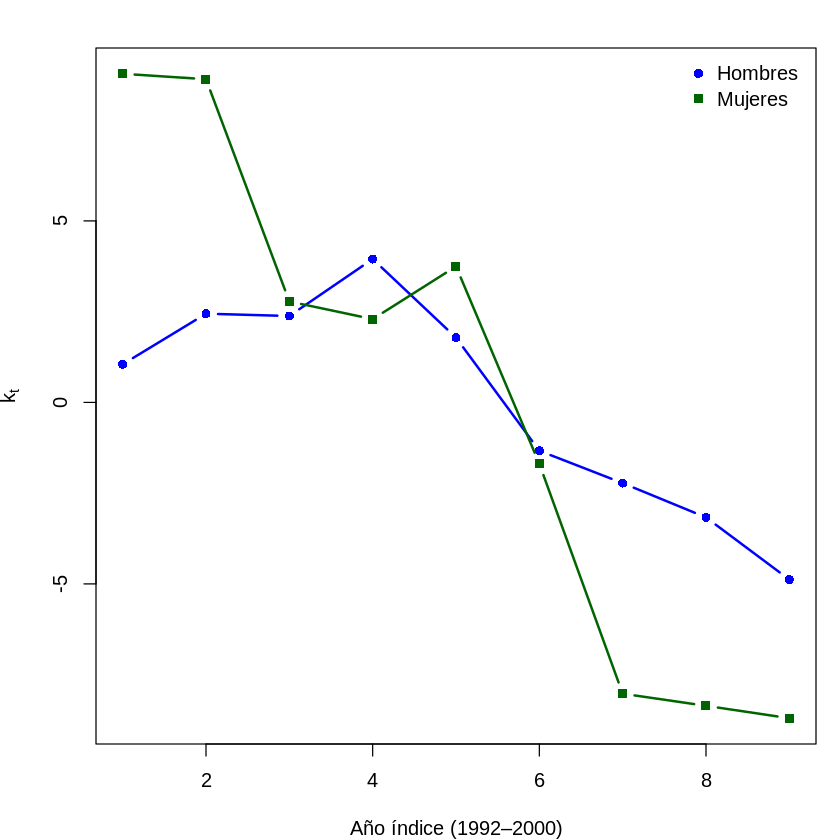

In [30]:
# Configura parametros graficos: una sola ventana de graficos (1x1) y margenes personalizados
par(mfrow = c(1,1), mar = c(4,4,2,1))

# Grafica la serie temporal k_t para hombres (1992–2000)
plot(1:length(kt.h.cl), kt.h.cl,
     type = "b",              # Lineas y puntos
     pch = 16,                # Simbolo para puntos (círculo relleno)
     lwd = 2,                 # Grosor de linea
     col = "blue",            # Color azul para hombres
     ylim = range(c(kt.h.cl, kt.m.cl)), # Escala vertical comun para hombres y mujeres
     xlab = "Año índice (1992–2000)",   # Etiqueta del eje X
     ylab = expression(k[t]))           # Etiqueta del eje Y con notacion matematica

# Agrega la serie k_t para mujeres sobre el mismo grafico
points(1:length(kt.m.cl), kt.m.cl,
       type = "b",            # Lineas y puntos
       pch = 15,              # Simbolo para puntos (cuadrado relleno)
       lwd = 2,               # Grosor de linea
       col = "darkgreen")     # Color verde oscuro para mujeres

# Agrega leyenda en la esquina superior derecha
legend("topright",
       legend = c("Hombres", "Mujeres"), # Etiquetas
       pch = c(16,15),                   # Simbolos correspondientes
       col = c("blue","darkgreen"),      # Colores correspondientes
       bty = "n")                        # Sin borde de caja

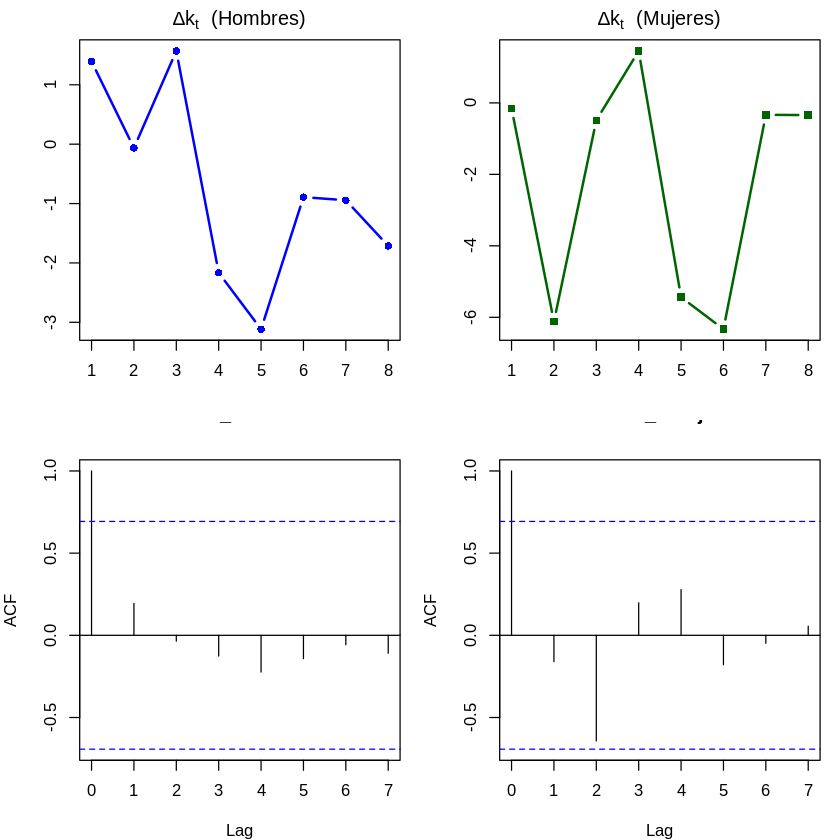

In [31]:
# Configura la ventana grafica para mostrar 4 graficos (2 filas × 2 columnas) con margenes personalizados
par(mfrow = c(2,2), mar = c(4,4,2,1))

# Grafica la primera diferencia de k_t para hombres
plot(diff(kt.h.cl), type = "b", pch = 16, lwd = 2, col = "blue",
     main = expression(Delta*k[t]~"(Hombres)"), # Titulo con notacion matematica
     ylab = "", xlab = "")                      # Sin etiquetas de ejes

# Grafica la primera diferencia de k_t para mujeres
plot(diff(kt.m.cl), type = "b", pch = 15, lwd = 2, col = "darkgreen",
     main = expression(Delta*k[t]~"(Mujeres)"), # Titulo con notacion matematica
     ylab = "", xlab = "")                      # Sin etiquetas de ejes

# Muestra la funcion de autocorrelacion (ACF) de la primera diferencia de k_t para hombres
acf(diff(kt.h.cl), main = "ACF Δk_t Hombres")

# Muestra la funcion de autocorrelacion (ACF) de la primera diferencia de k_t para mujeres
acf(diff(kt.m.cl), main = "ACF Δk_t Mujeres")

# Restablece la configuracion de la ventana grafica a una sola figura
par(mfrow = c(1,1))

In [32]:
# Ajusta un modelo ARIMA automaticamente para la serie k_t de hombres
fit.h <- auto.arima(kt.h.cl)   # Devuelve el modelo ARIMA optimo segun criterios estadisticos

# Ajusta un modelo ARIMA automaticamente para la serie k_t de mujeres
fit.m <- auto.arima(kt.m.cl)   # Devuelve el modelo ARIMA optimo segun criterios estadisticos

# Muestra el resumen del modelo ARIMA ajustado para hombres
fit.h

# Muestra el resumen del modelo ARIMA ajustado para mujeres
fit.m

Series: kt.h.cl 
ARIMA(0,1,0) 

sigma^2 = 2.929:  log likelihood = -15.65
AIC=33.3   AICc=33.97   BIC=33.38

Series: kt.m.cl 
ARIMA(0,1,0) 

sigma^2 = 13.72:  log likelihood = -21.83
AIC=45.65   AICc=46.32   BIC=45.73

In [33]:
# Define el numero de años a proyectar (2001–2050)
n.ahead <- 50

# Proyección de k_t para hombres usando un modelo ARIMA(0,1,0) sin estacionalidad
# S=0 indica que no se considera componente estacional
moh.cl <- sarima.for(kt.h.cl, n.ahead = n.ahead,
                     p = 0, d = 1, q = 0,   # Parametros del componente no estacional
                     P = 0, D = 0, Q = 0,   # Parametros del componente estacional
                     S = 0,                 # Periodo estacional inexistente
                     plot = FALSE)          # No mostrar grafico automatico

# Proyeccion de k_t para mujeres usando el mismo modelo ARIMA(0,1,0) sin estacionalidad
mom.cl <- sarima.for(kt.m.cl, n.ahead = n.ahead,
                     p = 0, d = 1, q = 0,
                     P = 0, D = 0, Q = 0,
                     S = 0,
                     plot = FALSE)

In [34]:
# Calcula la matriz de predicciones para mujeres (111 edades × 50 años proyectados)
# Formula del modelo Lee–Carter: m_x,t = exp(a_x + b_x * k_t) × 100000 (tasa por 100.000 habitantes)
pred.muj <- exp(
  ax.m.cl +                                      # Nivel promedio por edad
  bx.m.cl * matrix(mom.cl$pred,                  # Factor temporal proyectado
                   nrow = 111,                   # Numero de edades
                   ncol = n.ahead,               # Numero de años proyectados
                   byrow = TRUE)                 # Repetir k_t por filas
) * 100000                                          # Escala de tasas por 100,000

# Calcula la matriz de predicciones para hombres (111 edades × 50 años proyectados)
pred.hom <- exp(
  ax.h.cl +                                      # Nivel promedio por edad
  bx.h.cl * matrix(moh.cl$pred,                  # Factor temporal proyectado
                   nrow = 111,
                   ncol = n.ahead,
                   byrow = TRUE)
) * 100000

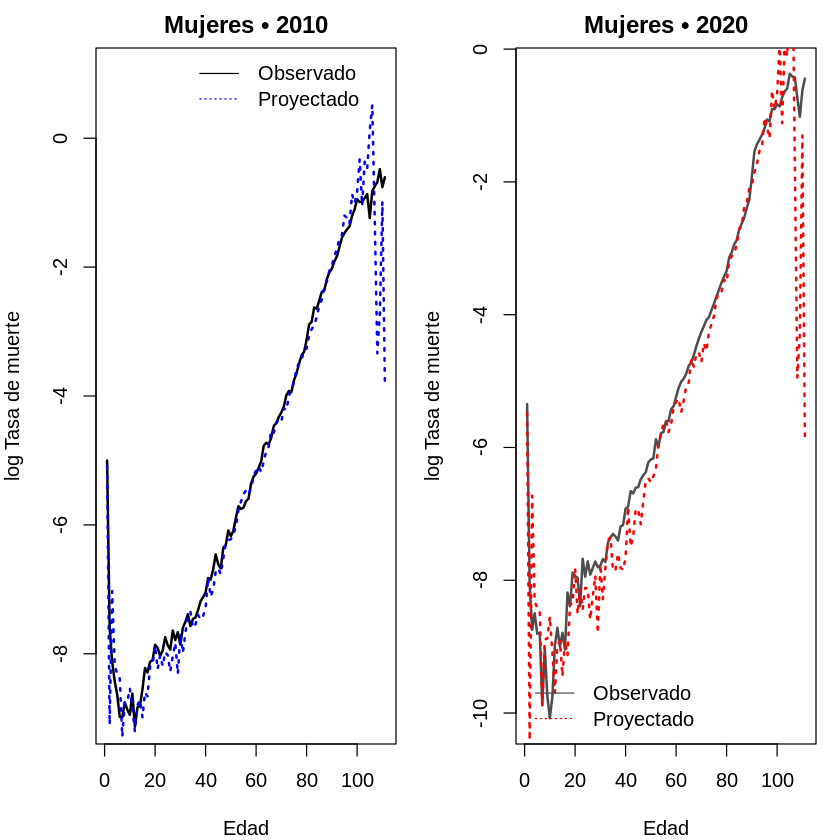

In [35]:
# Define las columnas correspondientes en los datos originales y en las proyecciones
k_obs_2010 <- 19   # Columna en el Excel para el año 2010 (observado)
k_pred_2010 <- 10  # Columna en las proyecciones (2000 + 10 = 2010)

# Configura la ventana grafica para mostrar dos graficos lado a lado
par(mfrow = c(1,2), mar = c(4,4,2,1))

# --- Grafico 1: Mujeres año 2010 ---
plot(1:111, log(unlist(ml.cl[, k_obs_2010])),  # Tasas observadas (log) para 2010
     type = "l", lwd = 2, col = "black",       # Linea negra continua
     xlab = "Edad", ylab = "log Tasa de muerte",
     main = "Mujeres • 2010", ylim = c(-9,1))  # Escala Y ajustada
lines(1:111, log(pred.muj[, k_pred_2010] / 1e5), # Tasas proyectadas (log) para 2010
      lwd = 2, col = "blue", lty = 3)           # Linea azul punteada
legend("topright", legend = c("Observado", "Proyectado"),
       lty = c(1,3), col = c("black","blue"), bty = "n")

# --- Grafico 2: Mujeres año 2020 ---
k_obs_2020 <- 29   # Columna en el Excel para 2020 (observado)
k_pred_2020 <- 20  # Columna en las proyecciones (2000 + 20 = 2020)

plot(1:111, log(unlist(ml.cl[, k_obs_2020])),  # Tasas observadas (log) para 2020
     type = "l", lwd = 2, col = "gray30",      # Linea gris oscuro
     xlab = "Edad", ylab = "log Tasa de muerte",
     main = "Mujeres • 2020")
lines(1:111, log(pred.muj[, k_pred_2020] / 1e5), # Tasas proyectadas (log) para 2020
      lwd = 2, col = "red", lty = 3)             # Linea roja punteada
legend("bottomleft", legend = c("Observado", "Proyectado"),
       lty = c(1,3), col = c("gray30","red"), bty = "n")

# Restablece la configuracion grafica a una sola figura
par(mfrow = c(1,1))

In [36]:
# Lee la hoja "CL_H_S" del archivo Excel, que contiene datos para hombres
hm.cl.s <- readxl::read_excel(ruta_excel, sheet = "CL_H_S")

# Reemplaza valores extremos en toda la hoja:
#   - Si la tasa es mayor a 1, se reemplaza por 1
#   - Si la tasa es igual a 0, se reemplaza por 1
# Esto evita problemas al aplicar logaritmos y corrige valores atipicos
hm.cl.s[] <- lapply(hm.cl.s, \(x) {
  x[x > 1 | x == 0] <- 1
  x
})

# Muestra las primeras filas del dataset corregido
head(hm.cl.s)

# Muestra las dimensiones del dataset (número de filas y columnas)
dim(hm.cl.s)

1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,⋯,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.016239,0.0150600,0.0136420,0.0126030,0.0129140,0.0113810,0.0120430,0.0116270,0.0102450,0.0098450,⋯,0.0081560,0.0080870,0.0078030,0.0078470,0.0078560,0.0075870,0.0074720,0.0075010,0.0072660,0.0069520
0.001563,0.0013720,0.0011910,0.0012840,0.0011230,0.0005280,0.0006810,0.0004290,0.0004640,0.0010340,⋯,0.0004930,0.0005360,0.0005720,0.0005370,0.0004280,0.0004880,0.0003470,0.0003910,0.0004910,0.0005400
0.000927,0.0005990,0.0006830,0.0006500,0.0005160,0.0007070,0.0009090,0.0006250,0.0007810,0.0005310,⋯,0.0004000,0.0003110,0.0002130,0.0002550,0.0003060,0.0002230,0.0002630,0.0002520,0.0003570,0.0003750
0.000738,0.0004690,0.0005050,0.0005000,0.0004360,0.0005020,0.0005160,0.0004190,0.0003840,0.0004470,⋯,0.0003360,0.0002290,0.0003040,0.0002060,0.0002710,0.0001610,0.0002320,0.0001810,0.0002520,0.0002120
0.003956,0.0035758,0.0032812,0.0030970,0.0030612,0.0026822,0.0029114,0.0026880,0.0024696,0.0024334,⋯,0.0019110,0.0018596,0.0018194,0.0018170,0.0018292,0.0017254,0.0016968,0.0016982,0.0017128,0.0016532
0.000760,0.0006202,0.0006342,0.0006436,0.0005412,0.0005016,0.0005686,0.0004224,0.0004666,0.0005166,⋯,0.0003194,0.0002882,0.0002942,0.0002754,0.0002934,0.0002430,0.0002408,0.0002174,0.0002844,0.0002924


[1] 111  28

In [37]:
# estim1()  —  version para tamaño (111 × 9)

estim1 <- function(set)
{
  T <- dim(set)[2]
  log(set) -> lml
  rowMeans(lml) -> a.x
  lml - matrix(rowMeans(lml), 111, 9) -> lml0
  svd(lml0, T, T) -> svdM
  (svd(lml0, T, T)$d) -> sv
  (sv[1]^2) / sum(sv^2)
  svdM$u[,1] / sum(svdM$u[,1]) -> b.x
  (svdM$v)[,1] * svdM$d[1] * sum(svdM$u[,1]) -> k.t
  list(a.x, b.x, k.t, (sv[1]^2) / sum(sv^2))
}

In [38]:
# Convierte el dataset a matriz eliminando la columna "Edad"
hm.mat <- as.matrix(hm.cl.s[ , !names(hm.cl.s) %in% "Edad"])

# Crea una base vacia para almacenar las proyecciones finales
# 111 filas (edades) y 0 columnas (inicialmente vacia)
BD.hm.cl <- matrix(nrow = 111, ncol = 0)

# Bucle de ventana movil (20 ventanas de 9 años cada una)
for (i in 1:20) {

  # Extrae la ventana de 9 años consecutivos
  # Ej.: 1992–2000, 1993–2001, etc.
  hm.cl.00 <- hm.mat[ , i:(i + 8), drop = FALSE]

  # Estima parametros Lee–Carter para la ventana
  ax.h <- estim1(hm.cl.00)[[1]]  # Nivel promedio por edad
  bx.h <- estim1(hm.cl.00)[[2]]  # Sensibilidad por edad
  kt.h <- estim1(hm.cl.00)[[3]]  # Factor temporal

  # Proyecta k_t 50 años hacia adelante con ARIMA(0,1,0) sin estacionalidad
  moh <- sarima.for(
           kt.h,
           n.ahead = 50,
           p = 0, d = 1, q = 0,     # Componente no estacional
           P = 0, D = 0, Q = 0,     # Componente estacional
           S = 0,                   # Sin estacionalidad
           no.constant = FALSE,
           plot = FALSE)

  # Crea la matriz de tasas proyectadas (111 edades × 50 años)
  predmr <- matrix(0, nrow = 0, ncol = 50)
  for (l in 1:111) {
    # Aplica formula Lee–Carter y escala a tasas por 100.000 habitantes
    fila <- t(exp(ax.h[l] + bx.h[l] * moh$pred)) * 100000
    predmr <- rbind(predmr, fila)
  }

  # Agrega el bloque proyectado a la base general
  # Dividido por 100.000 para volver a la escala de tasas 0–1
  BD.hm.cl <- cbind(BD.hm.cl, predmr / 100000)
}

# Comprobaciones rapidas
dim(BD.hm.cl)            # Dimensiones de la matriz final (→ 111 × 1000)
summary(BD.hm.cl[ , 1:5])# Resumen estadistico de las primeras 5 columnas
head(BD.hm.cl)           # Primeras filas de la matriz
dim(BD.hm.cl)            # Confirmacion de dimensiones

[1]  111 1000

       V1                 V2                 V3                 V4           
 Min.   :0.000246   Min.   :0.000242   Min.   :0.000238   Min.   :0.0002341  
 1st Qu.:0.001557   1st Qu.:0.001535   1st Qu.:0.001515   1st Qu.:0.0014939  
 Median :0.007899   Median :0.007786   Median :0.007676   Median :0.0075667  
 Mean   :0.111606   Mean   :0.114469   Mean   :0.117478   Mean   :0.1206392  
 3rd Qu.:0.086609   3rd Qu.:0.085630   3rd Qu.:0.084662   3rd Qu.:0.0837046  
 Max.   :0.839613   Max.   :0.844280   Max.   :0.853078   Max.   :0.9040593  
       V5           
 Min.   :0.0002095  
 1st Qu.:0.0014735  
 Median :0.0074592  
 Mean   :0.1239619  
 3rd Qu.:0.0827581  
 Max.   :0.9646549  

0.0103682124,0.0100597225,0.0097604112,0.0094700054,0.0091882402,0.0089148584,0.0086496108,0.0083922551,0.0081425567,0.0079002876,⋯,0.0047238244,0.0046742891,0.0046252732,0.0045767714,0.0045287781,0.0044812881,0.0044342961,4.387797e-03,4.341785e-03,4.296256e-03
0.0003532632,0.0003099950,0.0002720263,0.0002387081,0.0002094707,0.0001838144,0.0001613005,0.0001415442,0.0001242076,0.0001089945,⋯,0.0001965276,0.0001927070,0.0001889606,0.0001852871,0.0001816849,0.0001781529,0.0001746894,1.712933e-04,1.679633e-04,1.646979e-04
0.0007849784,0.0007984037,0.0008120585,0.0008259469,0.0008400728,0.0008544404,0.0008690536,0.0008839168,0.0008990341,0.0009144100,⋯,0.0009654298,0.0009924486,0.0010202236,0.0010487759,0.0010781273,0.0011083001,0.0011393173,1.171203e-03,1.203980e-03,1.237675e-03
0.0004172608,0.0004077245,0.0003984061,0.0003893008,0.0003804035,0.0003717095,0.0003632143,0.0003549132,0.0003468018,0.0003388758,⋯,0.0001109468,0.0001092304,0.0001075405,0.0001058767,0.0001042387,0.0001026260,0.0001010383,9.947513e-05,9.793615e-05,9.642098e-05
0.0024463227,0.0023686367,0.0022934177,0.0022205874,0.0021500699,0.0020817918,0.0020156819,0.0019516715,0.0018896937,0.0018296842,⋯,0.0011265206,0.0011154655,0.0011045188,0.0010936796,0.0010829467,0.0010723192,0.0010617960,1.051376e-03,1.041058e-03,1.030842e-03
0.0004318475,0.0004152012,0.0003991965,0.0003838088,0.0003690143,0.0003547900,0.0003411140,0.0003279652,0.0003153232,0.0003031685,⋯,0.0001612975,0.0001594807,0.0001576843,0.0001559082,0.0001541521,0.0001524157,0.0001506989,1.490015e-04,1.473232e-04,1.456638e-04


[1]  111 1000

In [39]:
# Post-procesamiento: asegura que las tasas no superen 1 (proporciones en escala 0–1)
BD.hm.cl[BD.hm.cl > 1] <- 1

# Exporta la matriz a Excel multiplicando por 100.000 para devolverla a escala de tasas por 100.000 habitantes
# El archivo se guardara en el directorio actual de trabajo (en Colab: /content/)
writexl::write_xlsx(as.data.frame(BD.hm.cl * 100000), "BD.hm.cl.xlsx")

# Mensaje de confirmacion en consola
cat("Archivo 'BD.hm.cl.xlsx' escrito en el directorio de trabajo\n")

Archivo 'BD.hm.cl.xlsx' escrito en el directorio de trabajo


In [40]:
# Calculo del Costo Neto Unitario (CNU) para edades desde 65 años (fila 67) hasta 110+
# Usa tasas de interes anuales del periodo 2000–2019 para el descuento

# Vector con tasas de interés (rho) para cada una de las 20 ventanas de proyección
rho <- c(0.0519, 0.0546, 0.0427, 0.0415, 0.0340,
         0.0347, 0.0325, 0.0328, 0.0390, 0.0367,
         0.0308, 0.0318, 0.0321, 0.0285, 0.0227,
         0.0276, 0.0238, 0.0274, 0.0280, 0.0139)

# Inicializa estructuras para almacenar resultados
matrix.cnu.hm.cl <- c()      # Matriz final (cada fila = edad, cada columna = ventana)
cnu.hm.cl <- rep(0, 20)      # Vector auxiliar para CNU en una edad especifica

# Bucle principal por edad (67 ≈ edad 65 en la matriz) hasta 111 (110+)
for (i in 67:111) {

  # Bucle por ventana de proyeccion (20 ventanas)
  for (k in 1:20) {
    r <- rho[k]              # Tasa de interes de la ventana k
    t <- 1 / (1 + r)         # Factor de descuento
    multiplicaciones <- c()  # Probabilidades acumuladas de sobrevivir
    m <- 1                   # Probabilidad inicial de supervivencia

    # Calculo de probabilidades acumuladas de supervivencia para la edad i-1 hacia adelante
    for (d in 1:(111 - i + 1)) {
      # Probabilidad de sobrevivir un año mas: 1 - tasa de mortalidad proyectada
      m <- m * (1 - BD.hm.cl[i - 1 + d, d + (k - 1) * 50])
      multiplicaciones <- cbind(multiplicaciones, m)
    }

    # Calculo de g: valor presente esperado de pagos, incluyendo t = 0
    g <- 1
    for (f in 1:(111 - i + 1)) {
      g <- g + multiplicaciones[f] * (t^f)
    }

    # Almacena el CNU para la ventana k
    cnu.hm.cl[k] <- g
  }

  # Añade la fila de CNU para la edad i al resultado final
  matrix.cnu.hm.cl <- rbind(matrix.cnu.hm.cl, t(cnu.hm.cl))
}

# Muestra los primeros resultados de CNU (edades 65–70)
head(matrix.cnu.hm.cl)

# Muestra las dimensiones de la matriz CNU
dim(matrix.cnu.hm.cl)

11.001717,10.626381,11.673226,12.20546,13.16616,13.39899,13.78867,13.44932,12.81451,13.03546,13.61790,14.03250,13.86893,14.14742,14.91787,14.63488,15.18262,15.01927,15.12007,16.97243
10.672437,10.319980,11.304090,11.81072,12.73694,12.97036,13.34687,13.01909,12.43024,12.63526,13.17538,13.58664,13.42163,13.67863,14.39890,14.15056,14.66046,14.52215,14.62721,16.34077
10.344337,10.012438,10.936079,11.41732,12.30510,12.53778,12.90090,12.58518,12.04052,12.23136,12.73008,13.13761,12.97490,13.20988,13.88237,13.66717,14.14086,14.02496,14.13300,15.71273
10.019804,9.705339,10.571861,11.03010,11.87525,12.10394,12.45131,12.14686,11.64273,11.82105,12.28098,12.68573,12.52981,12.74361,13.36999,13.18618,13.62509,13.52814,13.63760,15.08843
9.693851,9.396646,10.209716,10.64604,11.44963,11.67207,12.00213,11.70823,11.24050,11.40623,11.82939,12.23212,12.08542,12.27982,12.86234,12.70782,13.11213,13.03232,13.14164,14.47045
9.363529,9.086014,9.847832,10.26400,11.03338,11.24903,11.55953,11.27319,10.83653,10.98762,11.37567,11.77274,11.63902,11.81732,12.35866,12.23266,12.60284,12.53654,12.64568,13.85909


[1] 45 20

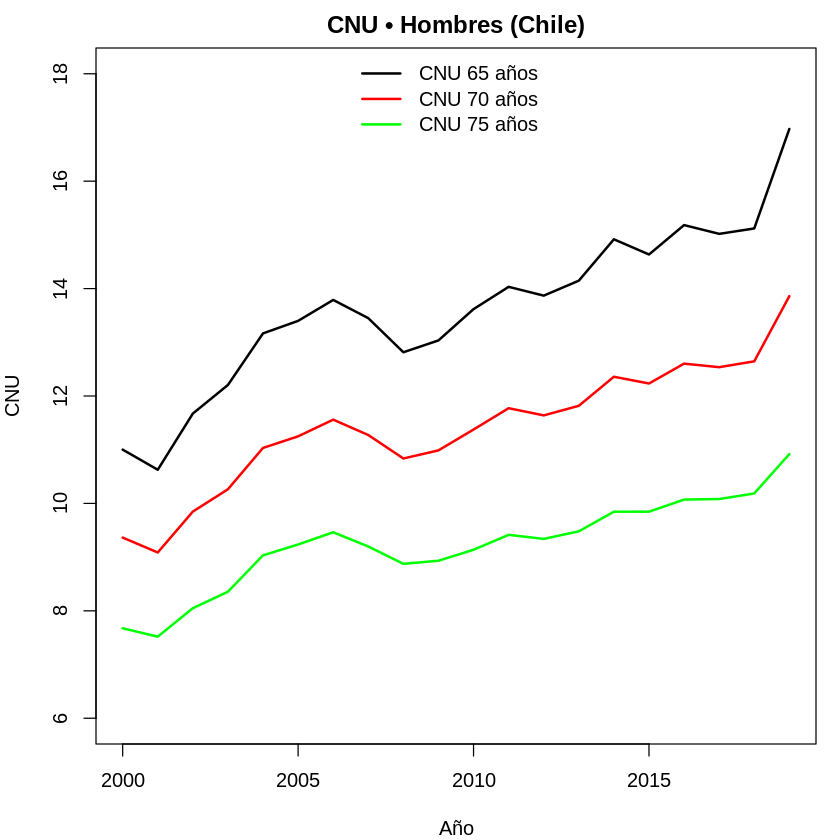

In [41]:
# Configura márgenes para el gráfico
par(mar = c(4,4,2,1))

# Grafica el CNU para la edad 75 años (fila 11 de la matriz: 65 + 10 años)
plot(2000:2019, matrix.cnu.hm.cl[11, ],
     type = "l", lwd = 2, col = "green",
     ylim = c(6, 18),                    # Rango en eje Y
     xlab = "Año", ylab = "CNU",
     main = "CNU • Hombres (Chile)")

# Agrega linea para la edad 65 años (fila 1 de la matriz)
lines(2000:2019, matrix.cnu.hm.cl[1, ],
      lwd = 2, col = "black")

# Agrega linea para la edad 70 años (fila 6 de la matriz)
lines(2000:2019, matrix.cnu.hm.cl[6, ],
      lwd = 2, col = "red")

# Agrega leyenda
legend("top",
       legend = c("CNU 65 años", "CNU 70 años", "CNU 75 años"),
       col    = c("black", "red", "green"),
       lty    = 1,
       lwd    = 2,
       bty    = "n")

In [42]:
# Lectura de porcentajes de poblacion para hombres desde distintos años base
# Se elimina la primera columna (edad) dejando solo porcentajes por año
porcentaje_poblacion00_cl_h <- read_excel(
  file.path("projects", "deuda-publica-pensiones-chile", "data", "% de la Población-00.xlsx"),
  sheet = "CL_H")[,-1]
porcentaje_poblacion04_cl_h <- read_excel(
  file.path("projects", "deuda-publica-pensiones-chile", "data", "% de la Poblacion-04.xlsx"),
  sheet = "CL_H")[,-1]
porcentaje_poblacion10_cl_h <- read_excel(
  file.path("projects", "deuda-publica-pensiones-chile", "data", "% de la Poblacion-10.xlsx"),
  sheet = "CL_H")[,-1]
porcentaje_poblacion15_cl_h <- read_excel(
  file.path("projects", "deuda-publica-pensiones-chile", "data", "% de la Población-15.xlsx"),
  sheet = "CL_H")[,-1]

# Lectura de tasas de crecimiento de la poblacion de 65+ años para hombres
creciemiento_cl_h <- read_excel(
  file.path("projects","deuda-publica-pensiones-chile","data","Tasas de Crecimiento (F).xlsx"),
  sheet = "CL_H")

# PIB de Chile (millones USD) para años 2000–2019, serie manual
pib_cl <- c(3442.99, 3298.37, 3178.73, 3318.13, 3808.60, 4513.42, 4996.72,
            5332.28, 5943.26, 6076.57, 7353.36, 8074.36, 8319.85, 8275.59,
            7623.91, 7029.97, 7032.71, 7796.25, 8203.33, 7825.44)

# Lectura de PIB desde archivo Excel
pib <- read_excel(
  file.path("projects","deuda-publica-pensiones-chile","data","Gasto Pensión PIB.xlsx"),
  sheet = "PIB_Nom")

# Tasas de interes a 10 años (2000–2019)
rho_cl <- c(0.0519, 0.0546, 0.0427, 0.0415, 0.0340, 0.0347, 0.0325, 0.0328, 0.0390, 0.0367,
            0.0308, 0.0318, 0.0321, 0.0285, 0.0227, 0.0276, 0.0238, 0.0274, 0.0280, 0.0139)

# Lectura de CNU proyectados para hombres, entregados por el docente
cnu.hm.cl_p <- read_excel(
  file.path("projects","deuda-publica-pensiones-chile","data","cnu.hm.cl.xlsx"))

# Inicializacion de vectores para valores presentes:
# VP1.cl.h = valor presente en el momento actual (año j)
# VP2.cl.h = valor presente de pagos futuros (desde t+1 en adelante)
VP1.cl.h <- rep(0, 20)
VP2.cl.h <- rep(0, 20)

New names:
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`


In [43]:
# Calculo de Valor Presente (VP) por quinquenio para hombres

# ---- Periodo 2000–2004 ----
for (j in 1:5) {  # Año dentro del quinquenio
  for (i in 1:36) {  # Edad desde 65 a 100+
    VP <- porcentaje_poblacion00_cl_h[j, i] *
          cnu.hm.cl_p[i, (j - 1) * 50 + j]   # CNU correspondiente
    VP1.cl.h[j] <- VP1.cl.h[j] + VP * pib_cl[j]  # Multiplica por PIB del año
  }
}
# VP para pagos futuros desde t+1
for (k in 1:5) {  # Ventana
  for (j in 1:50) {  # Año futuro proyectado
    for (i in 1:36) {
      VP <- ((creciemiento_cl_h[j, 2] + 1) *
             porcentaje_poblacion00_cl_h[j + 1, i] *
             cnu.hm.cl_p[i, j + 50 * (k - 1)]) / ((1 + rho_cl[k])^j)
      VP2.cl.h[k] <- VP2.cl.h[k] + VP * pib_cl[k]
    }
  }
}

# ---- Periodo 2005–2009 ----
for (j in 6:10) {
  for (i in 1:36) {
    VP <- porcentaje_poblacion04_cl_h[j - 5, i] *
          cnu.hm.cl_p[i, 250 + j + 50 * (j - 6)]
    VP1.cl.h[j] <- VP1.cl.h[j] + VP * pib_cl[j]
  }
}
for (k in 6:10) {
  for (j in 1:45) {
    for (i in 1:36) {
      VP <- ((creciemiento_cl_h[j, 3] + 1) *
             porcentaje_poblacion04_cl_h[j + 1, i] *
             cnu.hm.cl_p[i, k + 250 + 50 * (k - 6)]) / ((1 + rho_cl[k])^j)
      VP2.cl.h[k] <- VP2.cl.h[k] + VP * pib_cl[k]
    }
  }
}

# ---- Periodo 2010–2014 ----
for (j in 11:15) {
  for (i in 1:36) {
    VP <- porcentaje_poblacion10_cl_h[j - 10, i] *
          cnu.hm.cl_p[i, 500 + j + 50 * (j - 11)]
    VP1.cl.h[j] <- VP1.cl.h[j] + VP * pib_cl[j]
  }
}
for (k in 11:15) {
  for (j in 1:40) {
    for (i in 1:36) {
      VP <- ((creciemiento_cl_h[j, 4] + 1) *
             porcentaje_poblacion10_cl_h[j + 1, i] *
             cnu.hm.cl_p[i, k + 500 + 50 * (k - 11)]) / ((1 + rho_cl[k])^j)
      VP2.cl.h[k] <- VP2.cl.h[k] + VP * pib_cl[k]
    }
  }
}

# ---- Periodo 2015–2019 ----
for (j in 16:20) {
  for (i in 1:36) {
    VP <- porcentaje_poblacion15_cl_h[j - 15, i] *
          cnu.hm.cl_p[i, 750 + j + 50 * (j - 16)]
    VP1.cl.h[j] <- VP1.cl.h[j] + VP * pib_cl[j]
  }
}
for (k in 16:20) {
  for (j in 1:35) {
    for (i in 1:36) {
      VP <- ((creciemiento_cl_h[j, 5] + 1) *
             porcentaje_poblacion15_cl_h[j + 1, i] *
             cnu.hm.cl_p[i, k + 750 + 50 * (k - 15)]) / ((1 + rho_cl[k])^j)
      VP2.cl.h[k] <- VP2.cl.h[k] + VP * pib_cl[k]
    }
  }
}

# Calculo final de deuda previsional y relación con PIB

# Suma de VP actual + VP de pagos futuros
deuda.cl.h <- as.numeric(VP1.cl.h) + as.numeric(VP2.cl.h)

# Obtiene PIB correspondiente a los años 2000–2019 desde archivo Excel
pib.cl <- pib[1:20, 7]

# Calcula deuda como porcentaje del PIB
deuda_pib.cl.h <- deuda.cl.h / pib.cl

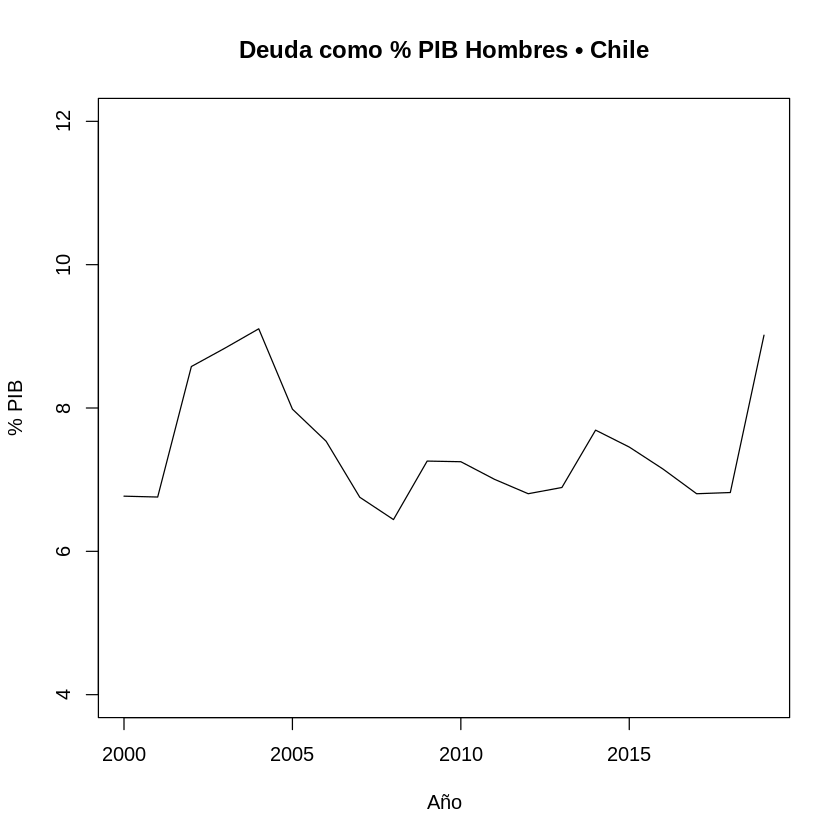

In [44]:
# Grafica la deuda previsional como porcentaje del PIB para hombres en Chile (2000–2019)
plot(2000:2019, t(deuda_pib.cl.h),
     type = "l",              # Linea continua
     ylab = "% PIB",          # Etiqueta del eje Y
     xlab = "Año",            # Etiqueta del eje X
     ylim = c(4, 12),         # Limite del eje Y
     main = "Deuda como % PIB Hombres • Chile")